In [55]:
## --------------- STEP 1 -------------------
#importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score)
os.makedirs('models', exist_ok=True)
print("Libraries Imported !")

Libraries Imported !


In [56]:
## ----------- Step 2 -----------
#loading the data
df=pd.read_csv('C:\\Users\\twnkl\\customer-churn-prediction\\data\\churn.csv')
print("Shape", df.shape)
df.head()

Shape (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


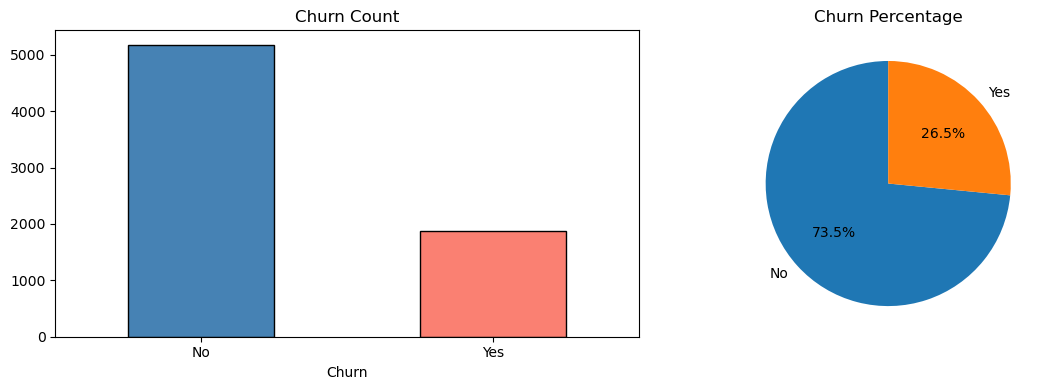

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [57]:
## -------------- Step 3 --------------
# EDA Distribution
fig, axes=plt.subplots(1, 2, figsize=(12,4))
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=["steelblue", "salmon"], edgecolor="black")
axes[0].set_title("Churn Count")
axes[0].tick_params(axis='x', rotation=0)

df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct="%1.1f%%", color=["steelblue", "salmon"], startangle=90)
axes[1].set_title("Churn Percentage")
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(df['Churn'].value_counts(normalize=True))

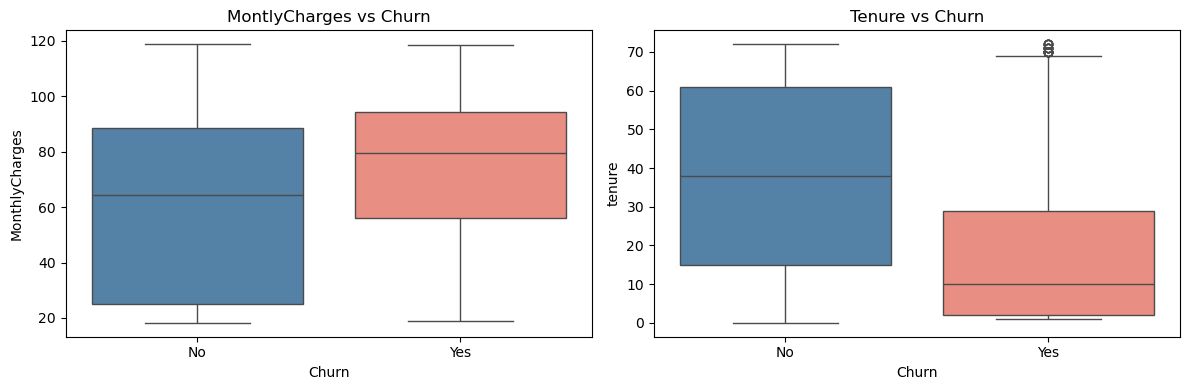

In [58]:
## ----------- Step 4 ------------
fig, axes= plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x="Churn", y="MonthlyCharges", hue='Churn', data=df, ax=axes[0], palette=['steelblue', 'salmon'], legend=False)
axes[0].set_title("MontlyCharges vs Churn")

sns.boxplot(x="Churn", y="tenure", hue='Churn', data=df, ax=axes[1], palette=['steelblue', 'salmon'], legend=False)
axes[1].set_title("Tenure vs Churn")

plt.tight_layout()
plt.show()

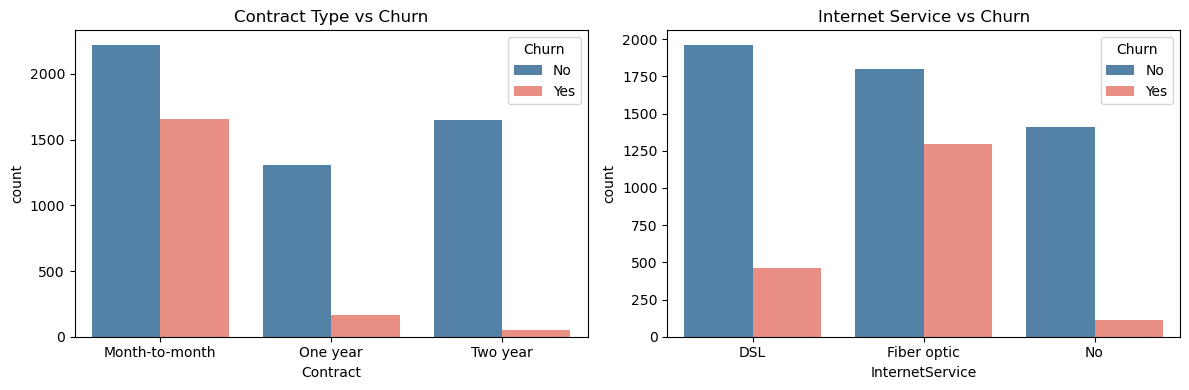

In [59]:
## ---------- Step 5 --------------
fig, axes= plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette=['steelblue', 'salmon'])
axes[0].set_title("Contract Type vs Churn")
axes[0].tick_params(axis='x')

sns.countplot(x="InternetService", hue='Churn', data=df, ax=axes[1], palette=['steelblue', 'salmon'])
axes[1].set_title("Internet Service vs Churn")

plt.tight_layout()
plt.show()

In [60]:
## ----------- Step 6 --------------
df_clean=df.copy()

df_clean.drop('customerID', axis=1, inplace=True)

df_clean['TotalCharges']=pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

df_clean['Churn']=df_clean['Churn'].map({'Yes':1, 'No':0})

le=LabelEncoder()
cat_cols=df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_clean[col]=le.fit_transform(df_clean[col])

print("Preprocessing Done!")
print("Missing values:", df_clean.isnull().sum().sum())
df_clean.head()

Preprocessing Done!
Missing values: 0


C:\Users\twnkl\AppData\Local\Temp\ipykernel_9444\1419233315.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [61]:
## --------------- Step 7 -------------
X=df_clean.drop('Churn', axis=1)
y=df_clean['Churn']
feature_names=X.columns.tolist()

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_train, X_test, y_train, y_test=train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train {X_train.shape[0]} samples")
print(f"Train {X_test.shape[0]} samples")

Train 5634 samples
Train 1409 samples


In [62]:
## -------------- Step 8 -------------
models={
    'Logistic Regression': LogisticRegression (max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results={}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test, y_pred)
    roc_auc=roc_auc_score(y_test, y_pred)
    results[name]={"accuracy":acc, "roc_auc":roc_auc}

    print(f"\n---{name}---")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC AUC : {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


---Logistic Regression---
Accuracy : 0.8155
ROC AUC : 0.7398
              precision    recall  f1-score   support

    No Churn       0.86      0.90      0.88      1036
       Churn       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409


---Random Forest---
Accuracy : 0.7970
ROC AUC : 0.6947
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1036
       Churn       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.79      1409



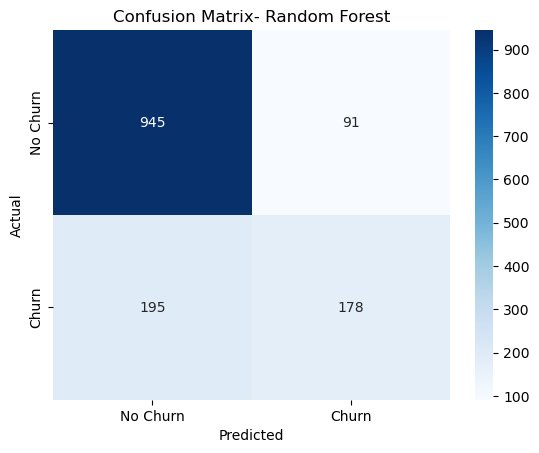

In [63]:
## ------------- Step 9 ------------
best_models=models["Random Forest"]
y_pred_best=best_models.predict(X_test)
cm=confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['No Churn', 'Churn'],
           yticklabels=['No Churn', 'Churn'])

plt.title("Confusion Matrix- Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

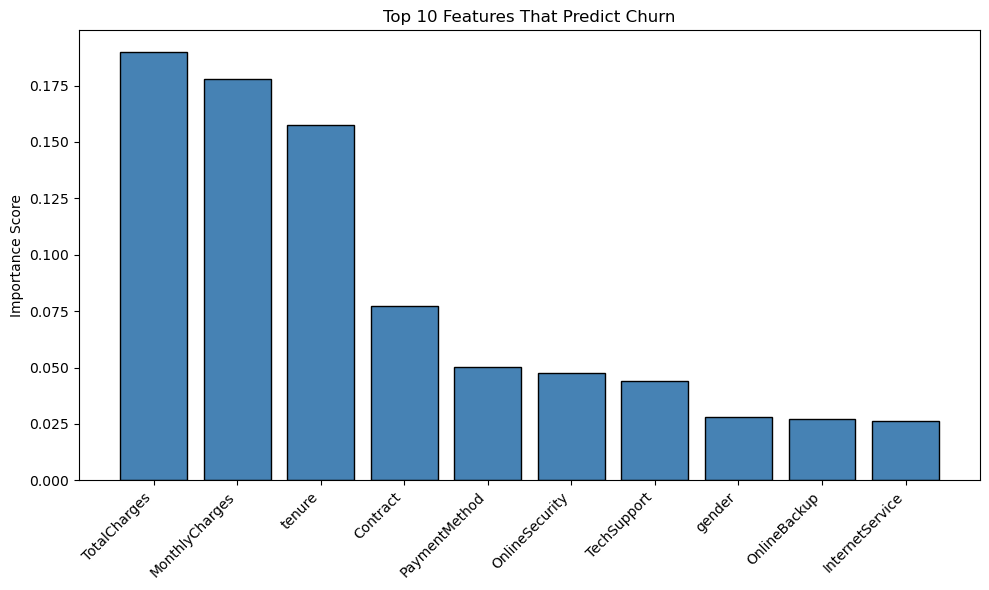

In [64]:
## ------------ Step 10 -----------------
importances=best_models.feature_importances_
indices=np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10,6))
plt.bar(range(10), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title("Top 10 Features That Predict Churn")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [65]:
## ---------- Step 11 -----------
joblib.dump(best_models, 'models/churn_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Model saved : churn_model.pkl")
print("Model saved : scaler model.pkl")
print("All done")

Model saved : churn_model.pkl
Model saved : scaler model.pkl
All done


In [66]:
import os
import joblib

# Check current working directory
print("You are here:", os.getcwd())

# Check if models folder exists, create if not
os.makedirs('models', exist_ok=True)
print("models folder exists:", os.path.exists('models'))

# Save the model
joblib.dump(best_models, 'models/churn_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

# Confirm files were saved
print("Files in models folder:", os.listdir('models'))

You are here: C:\Users\twnkl
models folder exists: True
Files in models folder: ['churn_model.pkl', 'scaler.pkl']
